# Quantum kernel training

In [1]:
# 下载并保存文件
!curl -o dataset_graph7.csv https://raw.githubusercontent.com/qiskit-community/prototype-quantum-kernel-training/main/data/dataset_graph7.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 49405  100 49405    0     0   397k      0 --:--:-- --:--:-- --:--:--  402k


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
 
from qiskit.circuit import Parameter, ParameterVector, QuantumCircuit
from qiskit.circuit.library import UnitaryOverlap
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
 
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
 
# from qiskit_serverless import IBMServerlessClient, QiskitFunction
from qiskit_ibm_catalog import QiskitServerless, QiskitFunction

获取数据集

In [3]:


def get_training_data():
    """Read the training data."""
    df = pd.read_csv("dataset_graph7.csv", sep=",", header=None)
    training_data = df.values[:20, :]
    ind = np.argsort(training_data[:, -1])
    X_train = training_data[ind][:, :-1]
 
    return X_train


In [4]:
def visualize_counts(res_counts, num_qubits, num_shots):
    """Visualize the outputs from the Qiskit Sampler primitive."""
    zero_prob = res_counts.get(0, 0.0)
    top_10 = dict(
        sorted(res_counts.items(), key=lambda item: item[1], reverse=True)[
            :10
        ]
    )
    top_10.update({0: zero_prob})
    by_key = dict(sorted(top_10.items(), key=lambda item: item[0]))
    x_vals, y_vals = list(zip(*by_key.items()))
    x_vals = [bin(x_val)[2:].zfill(num_qubits) for x_val in x_vals]
    y_vals_prob = []
    for t in range(len(y_vals)):
        y_vals_prob.append(y_vals[t] / num_shots)
    y_vals = y_vals_prob

    plt.bar(x_vals, y_vals)
    plt.xticks(rotation=75)
    plt.title("Results of sampling")
    plt.xlabel("Measured bitstring")
    plt.ylabel("Probability")
    plt.show()

构造量子核函数

In [5]:
X_train = get_training_data()

# Empty kernel matrix
num_samples = X_train.shape[0]
kernel_matrix = np.full((num_samples, num_samples), np.nan)

## 量子电路搭建

这个地方为了适应NISQ 时代的量子bit，在一个量子比特上“塞”进了两个特征
```
num_qubits = int(num_features / 2)
```

在这里，我们把布洛赫球（Bloch Sphere）当成了一个“坐标系统”：

- rx (绕 X 轴旋转)：就像是调节指针的上下位置（改变纬度）。

- rz (绕 Z 轴旋转)：就像是调节指针的左右位置（改变经度）。

对应的是

```
for i in range(num_qubits):
    fm.rz(-2 * feature_params[2 * i + 1], i)
    fm.rx(-2 * feature_params[2 * i], i)
```

编号的逻辑是：

假设你的数据 $x = [x_0, x_1, x_2, x_3, ...]$：
- 当 $i=0$ (第 0 号比特)：它抓取 feature_params[0] ($x_0$) 做 RX 旋转（x轴）。它抓取 feature_params[1] ($x_1$) 做 RZ 旋转（z轴）。
- 当 $i=1$ (第 1 号比特)：它抓取 feature_params[2] ($x_2$) 做 RX 旋转。它抓取 feature_params[3] ($x_3$) 做 RZ 旋转。

现在考虑数据之间的关系，捕捉特征之间的“相互作用” (Feature Interaction)

特征往往不是孤立的。

例子：假设你在判断一个人的健康状况。特征 A 是“身高”，特征 B 是“体重”。

如果没有 CZ，量子比特 0 只知道身高，比特 1 只知道体重。

这个里面由于量子硬件的问题，如果你强行让不相邻的比特“握手”，量子计算机会自动插入很多额外的门（SWAP 门）来搬运信息。这会导致线路变得极其臃肿，产生大量的噪声和错误
在这里我们采用的是[[0, 2], [3, 4], [2, 5], [1, 4], [2, 3], [4, 6]]这几个bit相联

## 总结来说：

- 单体旋转（RX/RZ）：这是个体阶段。每个量子比特只管把属于自己的那部分数据特征带进量子世界。就像是在给每一个数据点在布洛赫球上找一个位置。

- CZ门纠缠：这是“社会化”阶段。通过这些选定的“握手”，让原本独立的特征产生化学反应，挖掘出“如果特征A是这样，且特征B是那样”的深层逻辑。 



In [6]:
# Prepare feature map for computing overlap
num_features = X_train.shape[1]
num_qubits = int(num_features / 2)

entangler_map = [[0, 2], [3, 4], [2, 5], [1, 4], [2, 3], [4, 6]]

fm = QuantumCircuit(num_qubits)
training_param = Parameter("θ")
# 这里 我们放了一个训练参数，这个参数是用来控制量子电路的旋转的

feature_params = ParameterVector("x", num_qubits * 2)
# 这里 我们放了一个参数矢量 是在定义一个“参数容器”。它告诉程序：“我要预留一排位置，用来存放我的数据 X”
fm.ry(training_param, fm.qubits)

for cz in entangler_map:
    fm.cz(cz[0], cz[1])
    
for i in range(num_qubits):
    fm.rz(-2 * feature_params[2 * i + 1], i)
    fm.rx(-2 * feature_params[2 * i], i)

如果类比传统ML，他这个里面的np.pi / 2就是初始权重，对应的是布洛赫球的Y轴的旋转：

```
fm.ry(training_param, fm.qubits)
```

在这里面 我们抽出了14 和 19号样本，分别把他们注入到量子电路中，

在量子线路中，UnitaryOverlap(U1, U2) 实际上执行的是：$$U_2^\dagger U_1$$这里的 $U_2^\dagger$（读作 U2 dagger）就是 $U_2$ 的逆变换。
- 第一步 ($U_1$)：从初始状态 $|0\rangle$ 开始，按照样本 $x_1$ 的指令，在量子空间里走一段路，到达位置 $|\psi_1\rangle$。
- 第二步 ($U_2^\dagger$)：从 $|\psi_1\rangle$ 出发，按照样本 $x_2$ 的相反指令往回走。

把它们连起来看，整个 overlap_circ 的过程就是：$$|0\rangle \xrightarrow{+x_1} \text{旋转} \xrightarrow{+\pi/2} \text{旋转} \xrightarrow{-\pi/2} \text{反向旋转} \xrightarrow{-x_2} \text{反向旋转} \rightarrow \text{终点}$$

C:\Users\sjc20\AppData\Local\Temp\ipykernel_24992\3374244321.py:8: DeprecationWarning: The class ``qiskit.circuit.library.overlap.UnitaryOverlap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.unitary_overlap instead.
  overlap_circ = UnitaryOverlap(unitary1, unitary2)


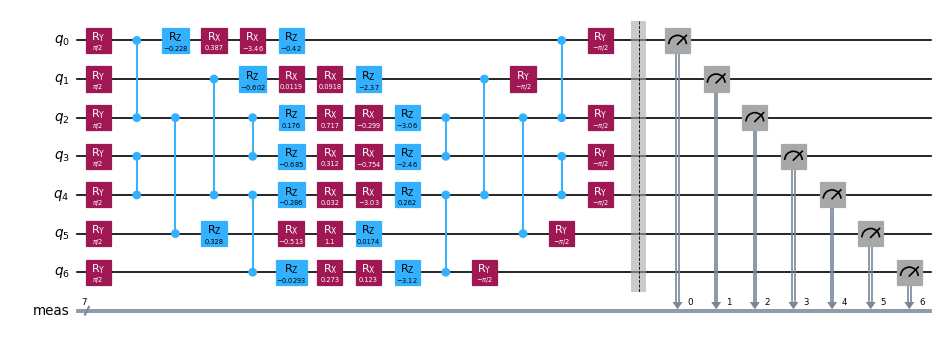

In [7]:

# Assign tunable parameter to known optimal value and set the data params for first two samples
x1 = 14
x2 = 19
unitary1 = fm.assign_parameters(list(X_train[x1]) + [np.pi / 2])
unitary2 = fm.assign_parameters(list(X_train[x2]) + [np.pi / 2])
 
# Create the overlap circuit
overlap_circ = UnitaryOverlap(unitary1, unitary2)
overlap_circ.measure_all()
overlap_circ.draw("mpl", scale=0.6, style="iqp")

寻找最佳设备

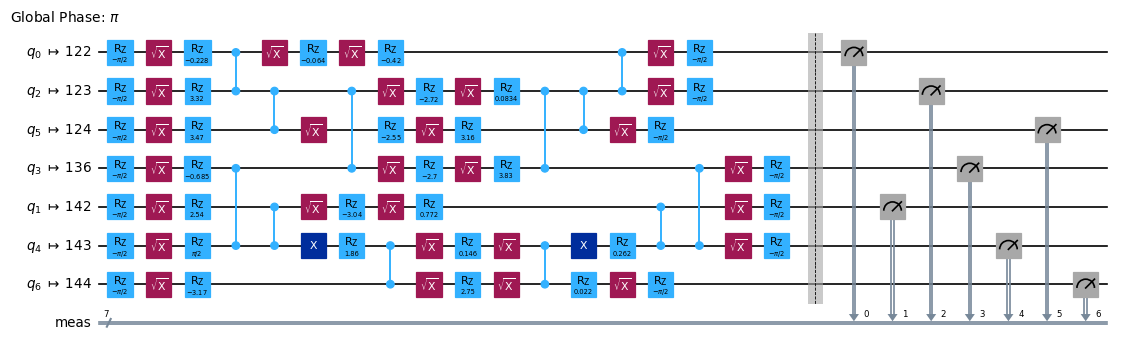

In [9]:
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=overlap_circ.num_qubits
)
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
overlap_ibm = pm.run(overlap_circ)
overlap_ibm.draw("mpl", scale=0.6, idle_wires=False, fold=-1, style="iqp")

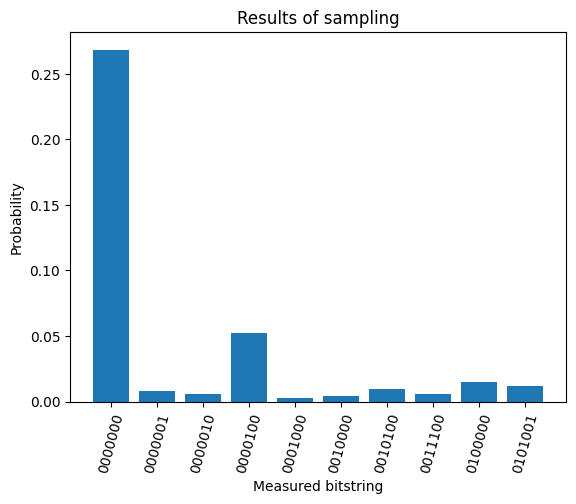

In [10]:
num_shots = 10_000
 
## Evaluate the problem using statevector-based primitives from Qiskit
# from qiskit.primitives import StatevectorSampler
 
# sampler = StatevectorSampler()
# results = sampler.run([overlap_circ]).result()
# counts = results[0].data.meas.get_int_counts()
 
# Evaluate the problem using a QPU via Qiskit IBM Runtime
 
sampler = Sampler(mode=backend)
results = sampler.run([overlap_ibm]).result()
counts = results[0].data.meas.get_int_counts()
 
visualize_counts(counts, num_qubits, num_shots)

In [11]:
# Calculate the fidelity, or the probability to measure 0
kernel_matrix[x1, x2] = counts.get(0, 0.0) / num_shots
print(f"Fidelity: {kernel_matrix[x1, x2]}")

Fidelity: 0.2684


In [12]:
# 使用模拟器（理想情况）
from qiskit.primitives import StatevectorSampler

sampler_ideal = StatevectorSampler()
results_ideal = sampler_ideal.run([overlap_circ]).result()
counts_ideal = results_ideal[0].data.meas.get_int_counts()

ideal_fidelity = counts_ideal.get(0, 0.0) / sum(counts_ideal.values())
print(f"理想保真度（模拟器）: {ideal_fidelity}")
print(f"真实设备保真度: {kernel_matrix[x1, x2]}")
print(f"差异: {abs(ideal_fidelity - kernel_matrix[x1, x2])}")

理想保真度（模拟器）: 0.7001953125
真实设备保真度: 0.2684
差异: 0.4317953125


In [13]:
kernel_matrix

array([[   nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
           nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
           nan,    nan,    nan,    nan],
       [   nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
           nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
           nan,    nan,    nan,    nan],
       [   nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
           nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
           nan,    nan,    nan,    nan],
       [   nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
           nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
           nan,    nan,    nan,    nan],
       [   nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
           nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
           nan,    nan,    nan,    nan],
       [   nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
   